# Customer Segmentation 

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
RANDOM_STATE = 42

In [3]:
df = pd.read_csv("customer_data.csv")
df.shape

(10000, 42)

In [4]:
df.head()

,Customer_ID,Birth_Year,Education_Level,Marital_Status,Annual_Income,Kids_Home,Teens_Home,Customer_Since,Last_Purchase_Recency,Spent_Wine,...,Mobile_App_User,Email_Subscriber,Device_Type,Referred_By_Friend,Social_Media_User,Membership_Tier,Total_Amount_Spent,Customer_Age,Family_Size,Senior_Citizen
0,1,1978,Graduation,Widow,40175.23,1,1,26-09-2010,68,440,...,1,0,Desktop,1,1,Silver,1265,47,2,0
1,2,1991,PhD,Widow,27979.68,0,1,03-11-2012,99,826,...,1,1,Desktop,1,0,Basic,1647,34,1,0
2,3,1968,PhD,Married,64747.68,0,0,31-10-2013,63,895,...,0,0,Desktop,0,1,Silver,1806,57,1,0
3,4,1954,Graduation,Widow,50185.85,2,2,30-04-2010,65,127,...,0,1,Mobile,0,1,Basic,1207,71,4,1
4,5,1982,Graduation,Married,53163.09,1,2,25-09-2015,49,140,...,0,1,Mobile,1,1,Basic,934,43,4,0


In [5]:
df.columns.tolist()

['Customer_ID',
 'Birth_Year',
 'Education_Level',
 'Marital_Status',
 'Annual_Income',
 'Kids_Home',
 'Teens_Home',
 'Customer_Since',
 'Last_Purchase_Recency',
 'Spent_Wine',
 'Spent_Fruits',
 'Spent_Meat',
 'Spent_Fish',
 'Spent_Sweets',
 'Spent_Gold',
 'Deals_Purchased',
 'Web_Purchases',
 'Catalog_Purchases',
 'Store_Purchases',
 'Monthly_Web_Visits',
 'Campaign1_Accepted',
 'Campaign2_Accepted',
 'Campaign3_Accepted',
 'Campaign4_Accepted',
 'Campaign5_Accepted',
 'Filed_Complaint',
 'Contact_Cost',
 'Revenue_Contribution',
 'Campaign_Response',
 'Country',
 'City',
 'Region_Code',
 'Mobile_App_User',
 'Email_Subscriber',
 'Device_Type',
 'Referred_By_Friend',
 'Social_Media_User',
 'Membership_Tier',
 'Total_Amount_Spent',
 'Customer_Age',
 'Family_Size',
 'Senior_Citizen']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            10000 non-null  int64  
 1   Birth_Year             10000 non-null  int64  
 2   Education_Level        10000 non-null  object 
 3   Marital_Status         10000 non-null  object 
 4   Annual_Income          10000 non-null  float64
 5   Kids_Home              10000 non-null  int64  
 6   Teens_Home             10000 non-null  int64  
 7   Customer_Since         10000 non-null  object 
 8   Last_Purchase_Recency  10000 non-null  int64  
 9   Spent_Wine             10000 non-null  int64  
 10  Spent_Fruits           10000 non-null  int64  
 11  Spent_Meat             10000 non-null  int64  
 12  Spent_Fish             10000 non-null  int64  
 13  Spent_Sweets           10000 non-null  int64  
 14  Spent_Gold             10000 non-null  int64  
 15  Dea

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_ID,10000.0,5000.500000,2886.895680,1.00,2500.750,5000.500,7500.2500,10000.00
Birth_Year,10000.0,1970.798400,17.903223,1940.00,1956.000,1971.000,1986.0000,2001.00
Annual_Income,10000.0,49934.047232,14870.373127,-7845.63,39607.725,49966.965,60058.9475,109134.97
Kids_Home,10000.0,0.997300,0.818388,0.00,0.000,1.000,2.0000,2.00
Teens_Home,10000.0,0.989300,0.814894,0.00,0.000,1.000,2.0000,2.00
Last_Purchase_Recency,10000.0,49.592500,29.101686,0.00,25.000,49.000,75.0000,99.00
Spent_Wine,10000.0,497.928400,287.932884,0.00,245.000,500.000,747.0000,999.00
Spent_Fruits,10000.0,49.709000,28.852961,0.00,25.000,49.000,75.0000,99.00
Spent_Meat,10000.0,401.292100,230.822103,0.00,202.000,406.000,600.0000,799.00
Spent_Fish,10000.0,148.804400,86.715667,0.00,73.000,148.000,223.0000,299.00


##  Data quality checks


In [8]:
print("Total null values   :", df.isnull().sum().sum())
print("Duplicate rows      :", df.duplicated().sum())
print("Duplicate Customer_ID:", df["Customer_ID"].duplicated().sum())

Total null values   : 0
Duplicate rows      : 0
Duplicate Customer_ID: 0


In [9]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()
print("Numeric columns    :", len(numeric_cols))
print("Categorical columns:", categorical_cols)

Numeric columns    : 35
Categorical columns: ['Education_Level', 'Marital_Status', 'Customer_Since', 'Country', 'City', 'Device_Type', 'Membership_Tier']


In [10]:
for col in ["Education_Level", "Marital_Status", "Country", "City", "Device_Type", "Membership_Tier"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Education_Level ---
Education_Level
Graduation    5027
Master        2026
Basic         1976
PhD            971
Name: count, dtype: int64

--- Marital_Status ---
Marital_Status
Widow       2079
Divorced    2061
Single      1976
Married     1947
Together    1937
Name: count, dtype: int64

--- Country ---
Country
Brazil     2102
Germany    2047
India      1960
UK         1956
USA        1935
Name: count, dtype: int64

--- City ---
City
New York     2097
London       1998
São Paulo    1986
Berlin       1985
Mumbai       1934
Name: count, dtype: int64

--- Device_Type ---
Device_Type
Mobile     4926
Desktop    4091
Tablet      983
Name: count, dtype: int64

--- Membership_Tier ---
Membership_Tier
Basic       4003
Silver      2978
Gold        2006
Platinum    1013
Name: count, dtype: int64


In [11]:
# Negative values in numeric columns
neg = (df[numeric_cols] < 0).sum()
print(neg[neg > 0])

Annual_Income    5
dtype: int64


In [12]:

nunique = df.nunique().sort_values()
print(nunique.head(12))
print("\nConstant columns:", nunique[nunique == 1].index.tolist())

Revenue_Contribution    1
Contact_Cost            1
Campaign1_Accepted      2
Campaign2_Accepted      2
Campaign3_Accepted      2
Campaign4_Accepted      2
Filed_Complaint         2
Campaign5_Accepted      2
Campaign_Response       2
Referred_By_Friend      2
Email_Subscriber        2
Senior_Citizen          2
dtype: int64

Constant columns: ['Revenue_Contribution', 'Contact_Cost']


In [13]:
# Consistency checks between related columns
spent_cols = ["Spent_Wine", "Spent_Fruits", "Spent_Meat", "Spent_Fish", "Spent_Sweets", "Spent_Gold"]
print("Total_Amount_Spent == sum of Spent_* columns :", (df[spent_cols].sum(axis=1) == df["Total_Amount_Spent"]).all())
print("Customer_Age == 2025 - Birth_Year            :", ((2025 - df["Birth_Year"]) == df["Customer_Age"]).all())
print("Kids_Home + Teens_Home vs Family_Size corr    :", round(df[["Kids_Home","Teens_Home"]].sum(axis=1).corr(df["Family_Size"]), 2))
print("\nCountry vs City (a customer in Germany can be in Mumbai -> City is not tied to Country):")
print(pd.crosstab(df["Country"], df["City"]))

Total_Amount_Spent == sum of Spent_* columns : True
Customer_Age == 2025 - Birth_Year            : True
Kids_Home + Teens_Home vs Family_Size corr    : 0.92

Country vs City (a customer in Germany can be in Mumbai -> City is not tied to Country):
City     Berlin  London  Mumbai  New York  São Paulo
Country                                             
Brazil      434     411     401       427        429
Germany     418     396     383       441        409
India       382     407     387       422        362
UK          394     399     364       421        378
USA         357     385     399       386        408


### Findings from inspection
* No missing values and no duplicate rows / IDs - the dataset is cleaner than the old churn file.
* `Annual_Income` contains **negative values** (invalid) - same kind of issue as in the old notebook.
* `Contact_Cost` and `Revenue_Contribution` are **constants** (3 and 11) -> useless for clustering.
* `Customer_Since` is a text date (`dd-mm-yyyy`) -> convert to datetime and create a *tenure* feature.
* `Birth_Year` duplicates `Customer_Age` (age = 2025 − birth year); `Total_Amount_Spent` is exactly the sum of the six `Spent_*` columns; `Senior_Citizen` is derived from age.
* `City` is not consistent with `Country`, and `Region_Code` has ~900 unique codes (an ID-like column).

##  Data cleaning

In [14]:
neg_income = (df["Annual_Income"] < 0).sum()
median_income = df.loc[df["Annual_Income"] >= 0, "Annual_Income"].median()
df.loc[df["Annual_Income"] < 0, "Annual_Income"] = np.nan
df["Annual_Income"] = df["Annual_Income"].fillna(median_income)
print(f"Negative incomes fixed: {neg_income}  |  median used: {median_income:.2f}")
print("Negative values left :", (df.select_dtypes(include='number') < 0).sum().sum())

Negative incomes fixed: 5  |  median used: 49975.81
Negative values left : 0


In [15]:
for col in ["Education_Level", "Marital_Status", "Country", "City", "Device_Type", "Membership_Tier"]:
    df[col] = df[col].str.strip()
df[["Education_Level", "Marital_Status", "Country", "City", "Device_Type", "Membership_Tier"]].nunique()

Education_Level    4
Marital_Status     5
Country            5
City               5
Device_Type        3
Membership_Tier    4
dtype: int64

In [16]:
df["Customer_Since"] = pd.to_datetime(df["Customer_Since"], format="%d-%m-%Y")
reference_date = df["Customer_Since"].max()
df["Tenure_Years"] = ((reference_date - df["Customer_Since"]).dt.days / 365.25).round(2)
print("Reference date:", reference_date.date())
df[["Customer_Since", "Tenure_Years"]].head()

Reference date: 2015-12-31


,Customer_Since,Tenure_Years
0,2010-09-26,5.26
1,2012-11-03,3.16
2,2013-10-31,2.17
3,2010-04-30,5.67
4,2015-09-25,0.27


In [17]:

df["Total_Children"]     = df["Kids_Home"] + df["Teens_Home"]
df["Total_Purchases"]    = df[["Web_Purchases", "Catalog_Purchases", "Store_Purchases"]].sum(axis=1)
df["Campaigns_Accepted"] = df[[f"Campaign{i}_Accepted" for i in range(1, 6)]].sum(axis=1)
df[["Total_Children", "Total_Purchases", "Campaigns_Accepted"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Total_Children,10000.0,1.9866,1.150892,0.0,1.0,2.0,3.0,4.0
Total_Purchases,10000.0,13.4587,4.959290,0.0,10.0,13.0,17.0,27.0
Campaigns_Accepted,10000.0,2.5152,1.125031,0.0,2.0,3.0,3.0,5.0


In [18]:

print("Nulls     :", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
df.to_csv("cleaned_customer_data.csv", index=False)
print("Saved cleaned_customer_data.csv", df.shape)

Nulls     : 0
Duplicates: 0
Saved cleaned_customer_data.csv (10000, 46)


##  Exploratory data analysis

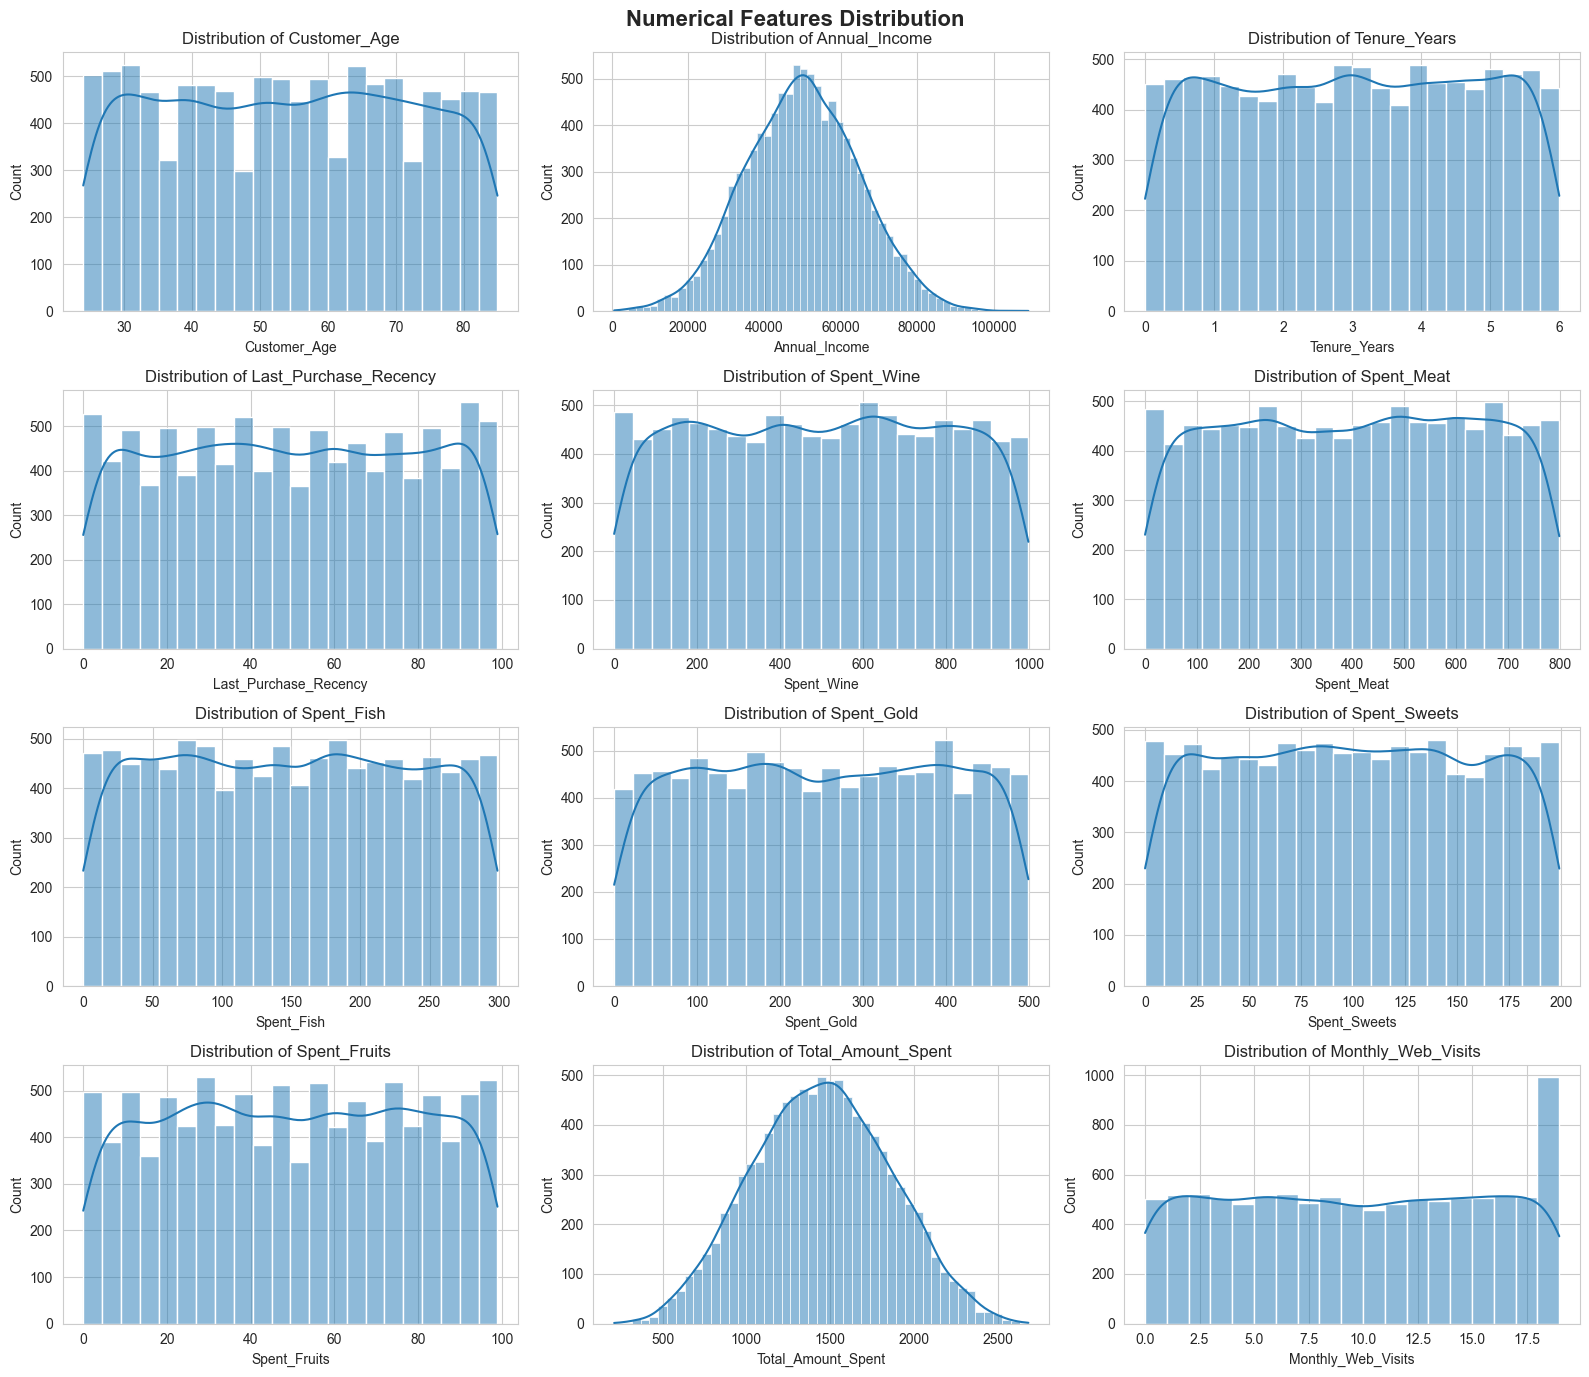

In [19]:
eda_cols = ["Customer_Age", "Annual_Income", "Tenure_Years", "Last_Purchase_Recency",
            "Spent_Wine", "Spent_Meat", "Spent_Fish", "Spent_Gold", "Spent_Sweets",
            "Spent_Fruits", "Total_Amount_Spent", "Monthly_Web_Visits"]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
for ax, col in zip(axes.flatten(), eda_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.suptitle("Numerical Features Distribution", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

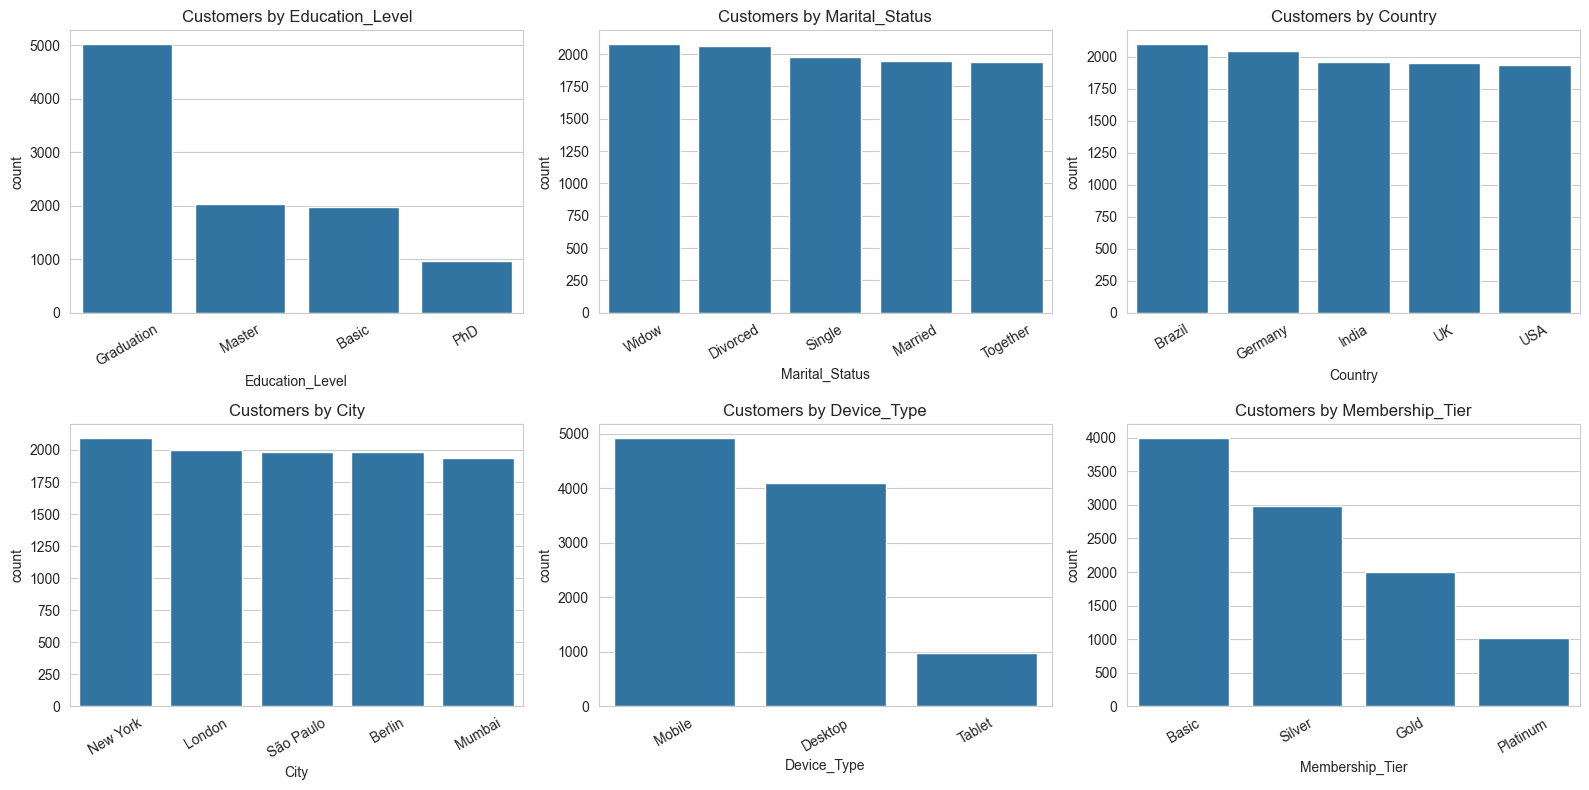

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), ["Education_Level", "Marital_Status", "Country", "City", "Device_Type", "Membership_Tier"]):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(f"Customers by {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

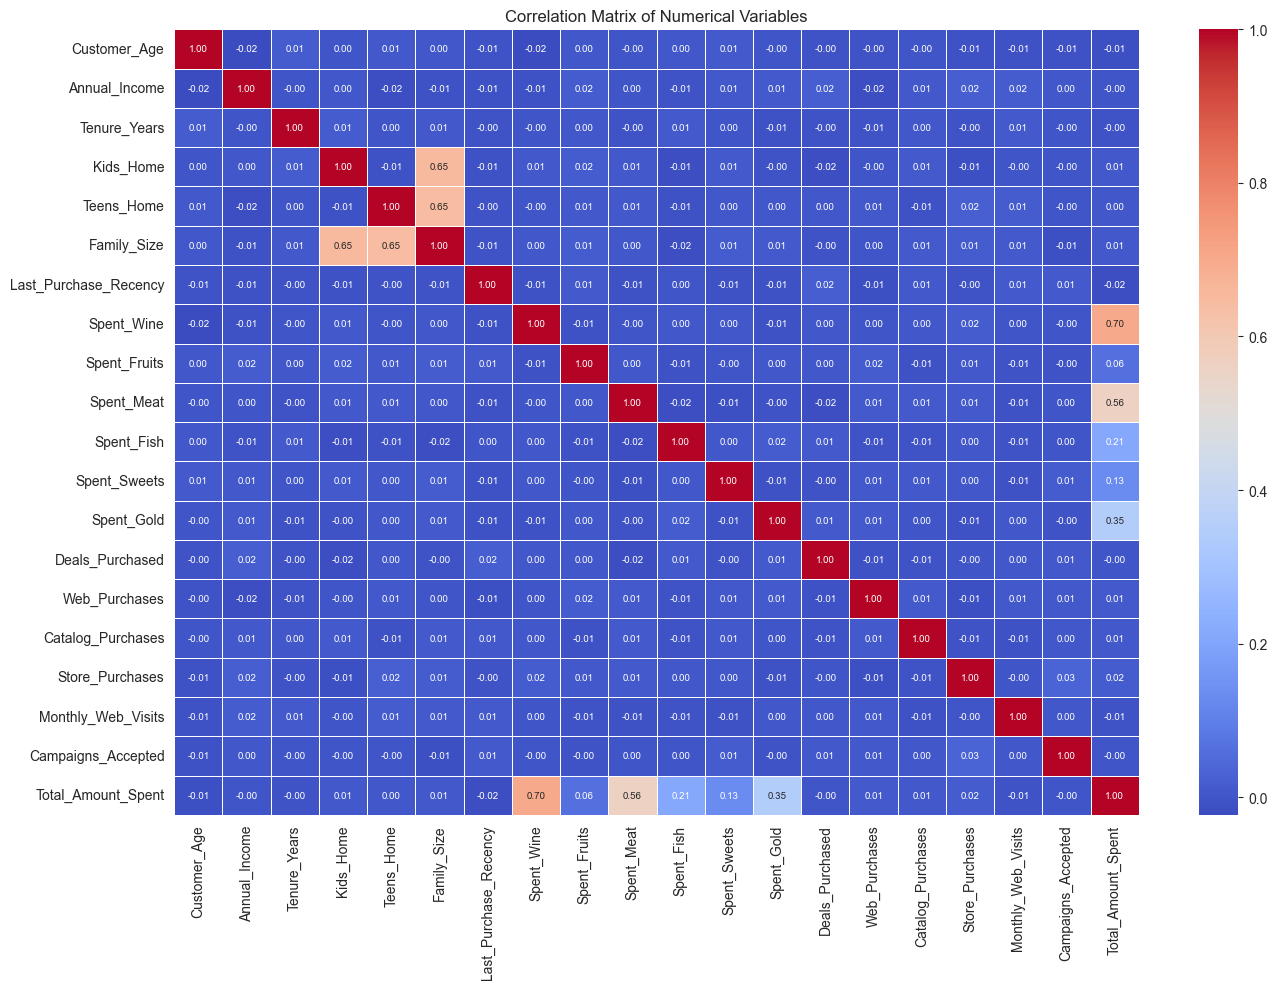

In [21]:
corr_cols = ["Customer_Age", "Annual_Income", "Tenure_Years", "Kids_Home", "Teens_Home", "Family_Size",
             "Last_Purchase_Recency", "Spent_Wine", "Spent_Fruits", "Spent_Meat", "Spent_Fish",
             "Spent_Sweets", "Spent_Gold", "Deals_Purchased", "Web_Purchases", "Catalog_Purchases",
             "Store_Purchases", "Monthly_Web_Visits", "Campaigns_Accepted", "Total_Amount_Spent"]
correlation = df[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, annot_kws={"size": 7})
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [22]:
# Strongest pairwise correlations
pairs = correlation.abs().where(np.triu(np.ones(correlation.shape), k=1).astype(bool)).stack().sort_values(ascending=False)
pairs.head(8)

Spent_Wine    Total_Amount_Spent    0.701638
Kids_Home     Family_Size           0.651928
Teens_Home    Family_Size           0.645584
Spent_Meat    Total_Amount_Spent    0.557522
Spent_Gold    Total_Amount_Spent    0.345430
Spent_Fish    Total_Amount_Spent    0.212317
Spent_Sweets  Total_Amount_Spent    0.130721
Spent_Fruits  Total_Amount_Spent    0.064872
dtype: float64

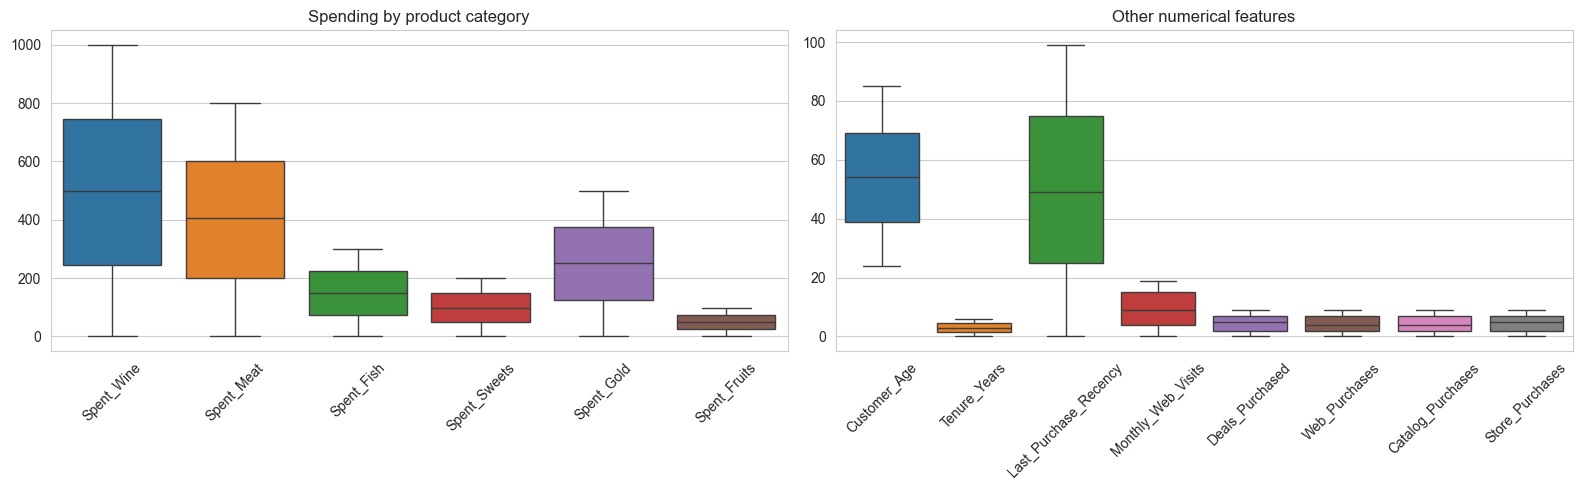

In [23]:
# Box plots (spend columns share a scale, so they are plotted together)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=df[["Spent_Wine", "Spent_Meat", "Spent_Fish", "Spent_Sweets", "Spent_Gold", "Spent_Fruits"]], ax=axes[0])
axes[0].set_title("Spending by product category")
sns.boxplot(data=df[["Customer_Age", "Tenure_Years", "Last_Purchase_Recency", "Monthly_Web_Visits",
                     "Deals_Purchased", "Web_Purchases", "Catalog_Purchases", "Store_Purchases"]], ax=axes[1])
axes[1].set_title("Other numerical features")
for ax in axes: ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# IQR outlier check (same method as the original notebook)
outlier_cols = ["Customer_Age", "Annual_Income", "Tenure_Years", "Last_Purchase_Recency",
                "Spent_Wine", "Spent_Fruits", "Spent_Meat", "Spent_Fish", "Spent_Sweets", "Spent_Gold",
                "Deals_Purchased", "Web_Purchases", "Catalog_Purchases", "Store_Purchases", "Monthly_Web_Visits"]
rows, total_outliers, total_values = [], 0, 0
for col in outlier_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = int(((df[col] < lower) | (df[col] > upper)).sum())
    rows.append({"Column": col, "Lower": round(lower, 2), "Upper": round(upper, 2),
                 "Outliers": n_out, "Outlier_%": round(n_out / len(df) * 100, 2)})
    total_outliers += n_out
    total_values += len(df)

display(pd.DataFrame(rows))
print(f"Overall outlier percentage: {total_outliers / total_values * 100:.2f}%")

,Column,Lower,Upper,Outliers,Outlier_%
0,Customer_Age,-6.00,114.00,0,0.00
1,Annual_Income,9019.78,90682.45,52,0.52
2,Tenure_Years,-3.06,9.10,0,0.00
3,Last_Purchase_Recency,-50.00,150.00,0,0.00
4,Spent_Wine,-508.00,1500.00,0,0.00
5,Spent_Fruits,-50.00,150.00,0,0.00
6,Spent_Meat,-395.00,1197.00,0,0.00
7,Spent_Fish,-152.00,448.00,0,0.00
8,Spent_Sweets,-97.00,295.00,0,0.00
9,Spent_Gold,-249.00,751.00,0,0.00


Overall outlier percentage: 0.03%


##  Preprocessing for unsupervised learning


In [25]:
drop_cols = ["Customer_ID", "Campaign_Response", "Contact_Cost", "Revenue_Contribution", "Birth_Year",
             "Total_Amount_Spent", "Senior_Citizen", "Customer_Since", "Region_Code", "City",
             "Total_Children", "Total_Purchases", "Campaigns_Accepted"]

df_cluster = df.drop(columns=drop_cols)

numeric_columns = df_cluster.select_dtypes(include="number").columns.tolist()
categorical_columns = df_cluster.select_dtypes(exclude="number").columns.tolist()
print("Numeric    :", len(numeric_columns))
print("Categorical:", categorical_columns)
print("Nulls      :", df_cluster.isnull().sum().sum())

Numeric    : 28
Categorical: ['Education_Level', 'Marital_Status', 'Country', 'Device_Type', 'Membership_Tier']
Nulls      : 0


### Convert categorical features to numerical (one-hot encoding)

In [26]:
df_encoded = pd.get_dummies(df_cluster, columns=categorical_columns, drop_first=False, dtype=int)
print(df_encoded.shape)
df_encoded.head()

(10000, 49)


,Annual_Income,Kids_Home,Teens_Home,Last_Purchase_Recency,Spent_Wine,Spent_Fruits,Spent_Meat,Spent_Fish,Spent_Sweets,Spent_Gold,...,Country_India,Country_UK,Country_USA,Device_Type_Desktop,Device_Type_Mobile,Device_Type_Tablet,Membership_Tier_Basic,Membership_Tier_Gold,Membership_Tier_Platinum,Membership_Tier_Silver
0,40175.23,1,1,68,440,34,473,215,58,45,...,0,0,0,1,0,0,0,0,0,1
1,27979.68,0,1,99,826,24,183,89,168,357,...,0,1,0,1,0,0,1,0,0,0
2,64747.68,0,0,63,895,2,315,104,195,295,...,0,0,0,1,0,0,0,0,0,1
3,50185.85,2,2,65,127,50,594,104,97,235,...,0,1,0,0,1,0,1,0,0,0
4,53163.09,1,2,49,140,49,74,213,173,285,...,0,1,0,0,1,0,1,0,0,0


### Feature scaling (StandardScaler)

In [27]:
X = df_encoded.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature matrix:", X_scaled.shape)

Feature matrix: (10000, 49)


## K-Means clustering
### Choosing K - elbow method and silhouette score

In [28]:
k_values = range(2, 11)
inertia_values, silhouette_values = [], []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({"K": list(k_values), "Inertia": inertia_values, "Silhouette_Score": silhouette_values})
results

  File "c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


,K,Inertia,Silhouette_Score
0,2,472186.660593,0.036406
1,3,461493.511263,0.039713
2,4,450749.709189,0.051463
3,5,438308.287139,0.063142
4,6,431943.394920,0.060726
5,7,428878.455237,0.031286
6,8,425396.064536,0.044140
7,9,419787.157743,0.042979
8,10,417053.959716,0.038337


In [29]:
best_k = int(results.loc[results["Silhouette_Score"].idxmax(), "K"])
print("Best K based on Silhouette Score:", best_k)
print("Highest Silhouette Score        :", round(results["Silhouette_Score"].max(), 4))

Best K based on Silhouette Score: 5
Highest Silhouette Score        : 0.0631


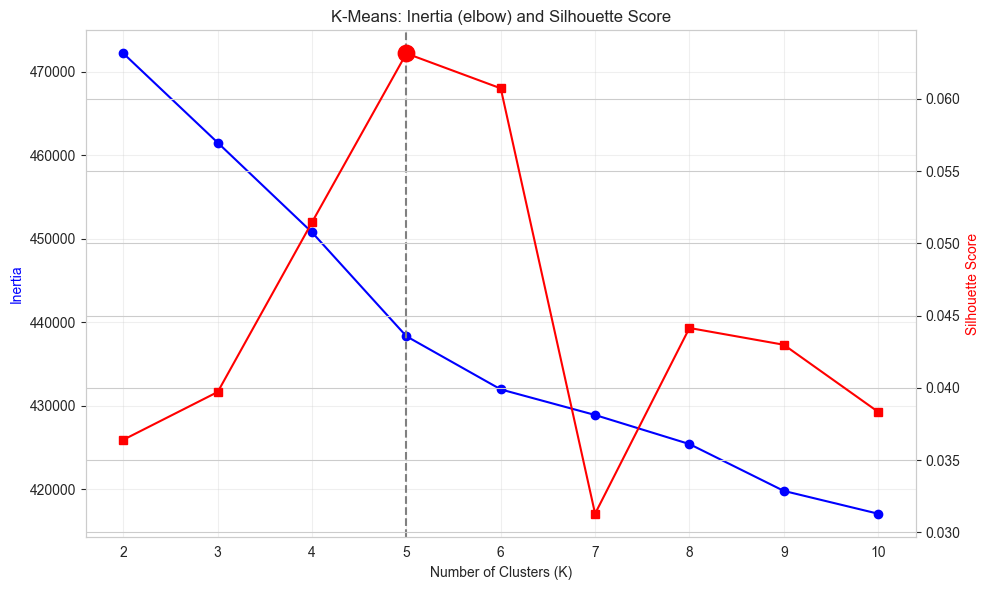

In [30]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(results["K"], results["Inertia"], marker="o", color="blue", label="Inertia")
ax1.set_xlabel("Number of Clusters (K)"); ax1.set_ylabel("Inertia", color="blue")
ax1.set_xticks(results["K"]); ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(results["K"], results["Silhouette_Score"], marker="s", color="red", label="Silhouette Score")
ax2.set_ylabel("Silhouette Score", color="red")
ax2.scatter(best_k, results["Silhouette_Score"].max(), color="red", s=140, zorder=5)
ax1.axvline(best_k, ls="--", color="grey")
plt.title("K-Means: Inertia (elbow) and Silhouette Score")
plt.tight_layout()
plt.show()

### Final K-Means model

In [31]:
final_kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = final_kmeans.fit_predict(X_scaled)

df_cluster = df.copy()                     
df_cluster["Cluster"] = kmeans_labels

print("Selected K       :", best_k)
print("Silhouette score :", round(silhouette_score(X_scaled, kmeans_labels), 4))
print("Inertia          :", round(final_kmeans.inertia_, 2))
print()
print(df_cluster["Cluster"].value_counts().sort_index())

Selected K       : 5
Silhouette score : 0.0631
Inertia          : 438308.29

Cluster
0    1937
1    1947
2    2079
3    2061
4    1976
Name: count, dtype: int64


In [32]:
# Cluster visualisation in PCA space
plt.figure(figsize=(9, 6))
for c in range(best_k):
    plt.scatter(X_pca[kmeans_labels == c, 0], X_pca[kmeans_labels == c, 1], s=12, alpha=0.6, label=f"Cluster {c}")
centers_pca = pca.transform(final_kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker="X", s=250, c="black", label="Centroids")
plt.xlabel("Principal Component 1"); plt.ylabel("Principal Component 2")
plt.title(f"K-Means Clusters (K={best_k}) using PCA")
plt.legend()
plt.show()

NameError: name 'X_pca' is not defined

<Figure size 900x600 with 0 Axes>

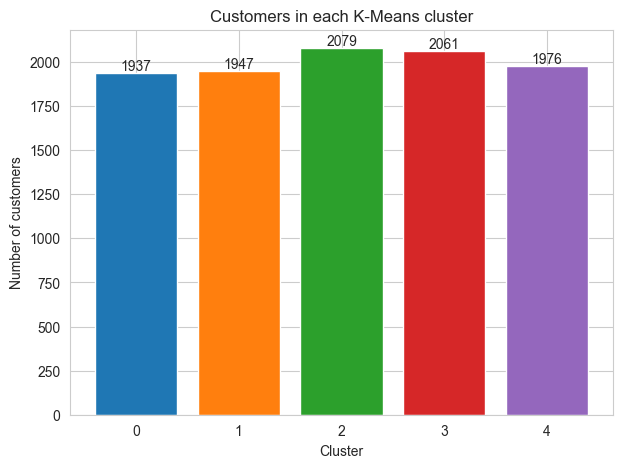

In [ ]:
counts = df_cluster["Cluster"].value_counts().sort_index()
plt.figure(figsize=(7, 5))
bars = plt.bar(counts.index.astype(str), counts.values, color=sns.color_palette("tab10", len(counts)))
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height(), int(b.get_height()), ha="center", va="bottom")
plt.xlabel("Cluster"); plt.ylabel("Number of customers"); plt.title("Customers in each K-Means cluster")
plt.show()

### Cluster profiling

In [ ]:
profile_cols = ["Customer_Age", "Annual_Income", "Tenure_Years", "Family_Size", "Last_Purchase_Recency",
                "Spent_Wine", "Spent_Fruits", "Spent_Meat", "Spent_Fish", "Spent_Sweets", "Spent_Gold",
                "Total_Amount_Spent", "Deals_Purchased", "Web_Purchases", "Catalog_Purchases",
                "Store_Purchases", "Monthly_Web_Visits", "Campaigns_Accepted", "Campaign_Response"]

cluster_profile = df_cluster.groupby("Cluster")[profile_cols].mean()
cluster_profile.round(2).T

Cluster,0,1,2,3,4
Customer_Age,54.11,54.29,54.43,54.44,53.71
Annual_Income,49786.80,50083.99,49751.83,49638.69,50564.55
Tenure_Years,3.03,2.99,3.00,3.02,3.03
Family_Size,3.01,2.96,2.03,1.96,1.98
Last_Purchase_Recency,49.98,49.66,49.31,49.51,49.51
Spent_Wine,487.39,509.50,498.79,497.49,496.41
Spent_Fruits,49.85,49.46,49.68,49.45,50.12
Spent_Meat,400.66,393.98,402.49,405.15,403.84
Spent_Fish,149.60,148.20,147.17,151.64,147.38
Spent_Sweets,100.63,100.51,97.60,98.63,99.39


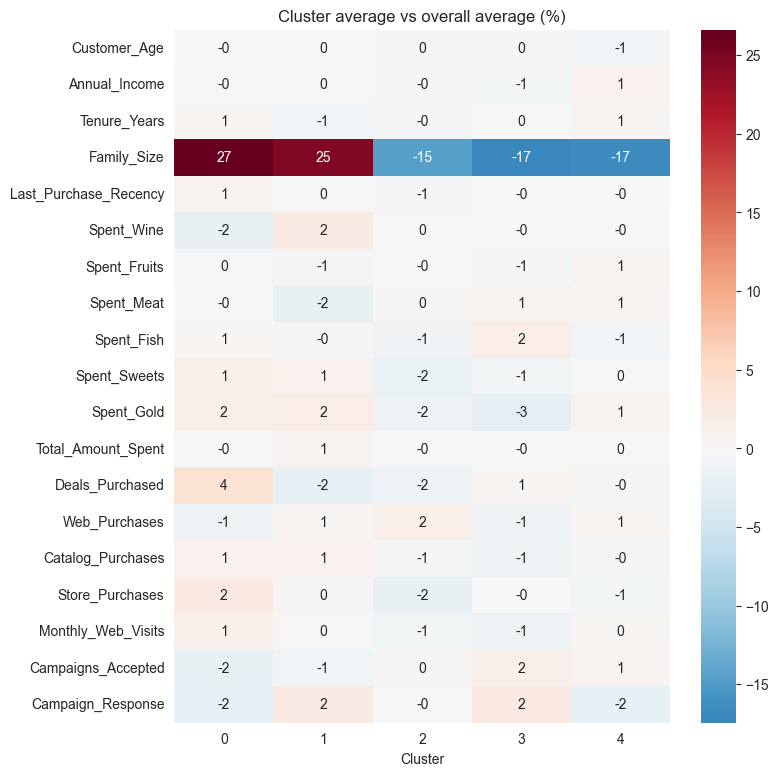

In [ ]:
# How far each cluster is from the overall average (in %), as a heatmap
overall_mean = df_cluster[profile_cols].mean()
diff_pct = (cluster_profile - overall_mean) / overall_mean * 100

plt.figure(figsize=(8, 9))
sns.heatmap(diff_pct.T, annot=True, fmt=".0f", cmap="RdBu_r", center=0)
plt.title("Cluster average vs overall average (%)")
plt.show()

In [ ]:
# Categorical make-up of every cluster (row %)
for col in ["Membership_Tier", "Education_Level", "Marital_Status", "Country", "Device_Type"]:
    print(f"\n--- {col} by Cluster (%) ---")
    print((pd.crosstab(df_cluster["Cluster"], df_cluster[col], normalize="index") * 100).round(1))


--- Membership_Tier by Cluster (%) ---
Membership_Tier  Basic  Gold  Platinum  Silver
Cluster                                       
0                 40.8  20.0      10.1    29.0
1                 40.4  19.6      10.9    29.1
2                 37.0  22.3       9.5    31.2
3                 41.4  19.5      10.5    28.6
4                 40.7  18.8       9.6    30.9

--- Education_Level by Cluster (%) ---
Education_Level  Basic  Graduation  Master   PhD
Cluster                                         
0                 19.6        50.1    20.6   9.7
1                 20.7        50.3    19.7   9.2
2                 18.6        50.7    20.8   9.9
3                 20.1        49.7    20.0  10.1
4                 19.9        50.4    20.1   9.6

--- Marital_Status by Cluster (%) ---
Marital_Status  Divorced  Married  Single  Together  Widow
Cluster                                                   
0                    0.0      0.0     0.0     100.0    0.0
1                    0.0    100.

In [ ]:
print((pd.crosstab(df_cluster["Cluster"], df_cluster["Campaign_Response"], normalize="index") * 100).round(1))

Campaign_Response     0     1
Cluster                      
0                  50.9  49.1
1                  48.7  51.3
2                  49.8  50.2
3                  48.5  51.5
4                  50.9  49.1


###  Name the segments
Names are assigned **after** clustering, from the cluster profiles above (they are labels for interpretation, not inputs to the model).
The profile tables show that the clusters are separated almost entirely by `Marital_Status` (and the family size that goes with it), so the names are built from the dominant marital status of each cluster.

In [ ]:
dominant_status = (
    df_cluster.groupby("Cluster")["Marital_Status"]
    .agg(lambda s: s.value_counts().index[0])
)
share = (
    df_cluster.groupby("Cluster")["Marital_Status"]
    .agg(lambda s: s.value_counts(normalize=True).iloc[0] * 100)
)
cluster_names = {c: f"{dominant_status[c]} customers" for c in dominant_status.index}

df_cluster["KMeans_Segment"] = df_cluster["Cluster"].map(cluster_names)
pd.DataFrame({"Segment": dominant_status.map(lambda x: f"{x} customers"),
              "Dominant_%": share.round(1),
              "Customers": df_cluster["Cluster"].value_counts().sort_index(),
              "Avg_Family_Size": cluster_profile["Family_Size"].round(2)})

,Segment,Dominant_%,Customers,Avg_Family_Size
Cluster,,,,
0,Together customers,100.0,1937,3.01
1,Married customers,100.0,1947,2.96
2,Widow customers,100.0,2079,2.03
3,Divorced customers,100.0,2061,1.96
4,Single customers,100.0,1976,1.98


The only structure K-Means picks up is the categorical `Marital_Status` column. Treat the segments as a *starting point* (and be careful about business conclusions), not as proof of distinct customer types.

##  Hierarchical clustering (Agglomerative)
### Dendrogram

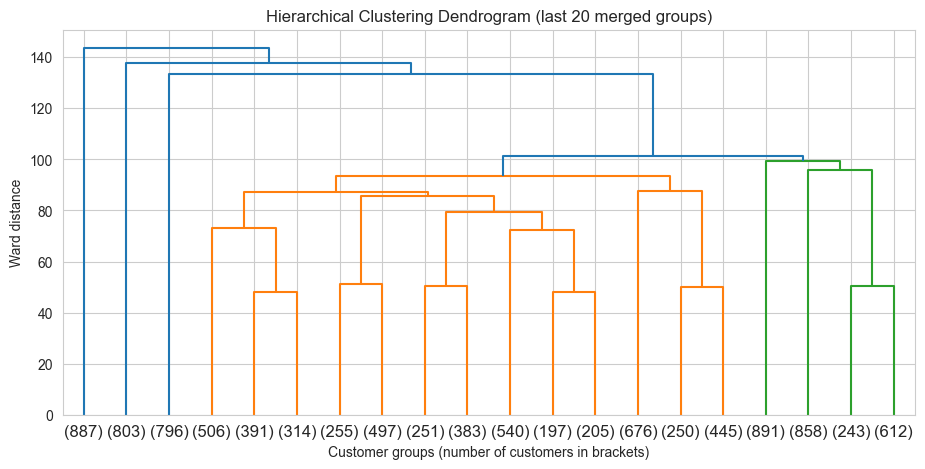

In [ ]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(11, 5))
dendrogram(Z, truncate_mode="lastp", p=20)
plt.title("Hierarchical Clustering Dendrogram (last 20 merged groups)")
plt.xlabel("Customer groups (number of customers in brackets)")
plt.ylabel("Ward distance")
plt.show()

### Choosing the number of clusters (same K range as K-Means, 2-10)

In [ ]:
from scipy.cluster.hierarchy import fcluster

hc_results = []
for k in range(2, 11):
    labels = fcluster(Z, t=k, criterion="maxclust") - 1      
    hc_results.append({"K": k, "Silhouette_Score": silhouette_score(X_scaled, labels)})
hc_results = pd.DataFrame(hc_results)

best_k_hc = int(hc_results.loc[hc_results["Silhouette_Score"].idxmax(), "K"])
print(hc_results)
print("\nBest K:", best_k_hc, "| Highest silhouette:", round(hc_results["Silhouette_Score"].max(), 4))

    K  Silhouette_Score
0   2          0.048919
1   3          0.052249
2   4          0.049840
3   5          0.026375
4   6          0.023416
5   7          0.019027
6   8          0.018244
7   9          0.015446
8  10          0.015547

Best K: 3 | Highest silhouette: 0.0522


In [ ]:
hc = AgglomerativeClustering(n_clusters=best_k_hc, linkage="ward")
df_cluster["Hierarchical_Cluster"] = hc.fit_predict(X_scaled)

print(df_cluster["Hierarchical_Cluster"].value_counts().sort_index())
df_cluster.groupby("Hierarchical_Cluster")[profile_cols].mean().round(2).T

Hierarchical_Cluster
0    8310
1     887
2     803
Name: count, dtype: int64


Hierarchical_Cluster,0,1,2
Customer_Age,54.10,54.48,54.90
Annual_Income,50031.46,50306.45,48844.69
Tenure_Years,3.01,2.97,3.13
Family_Size,2.37,2.38,2.38
Last_Purchase_Recency,49.59,48.25,51.13
Spent_Wine,500.37,490.30,481.04
Spent_Fruits,49.83,48.97,49.26
Spent_Meat,401.58,396.86,403.24
Spent_Fish,148.67,145.93,153.35
Spent_Sweets,99.01,101.48,100.19


In [ ]:
print("Hierarchical clusters vs Marital_Status (row %):")
(pd.crosstab(df_cluster["Hierarchical_Cluster"], df_cluster["Marital_Status"], normalize="index") * 100).round(1)

Hierarchical clusters vs Marital_Status (row %):


Marital_Status,Divorced,Married,Single,Together,Widow
Hierarchical_Cluster,,,,,
0,20.3,19.7,19.7,19.5,20.8
1,22.0,18.6,18.2,20.0,21.3
2,22.5,18.3,21.7,17.7,19.8


##  DBSCAN
###  k-distance plot to pick a sensible `eps`

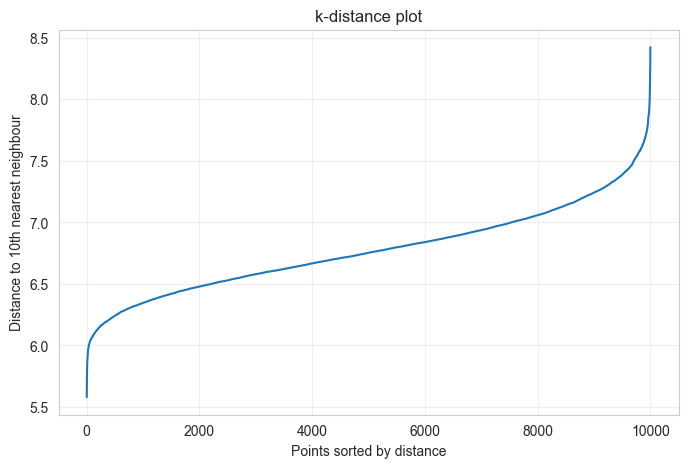

eps candidates: [6.75 6.94 7.14 7.39 7.68]


In [35]:
k_nn = 10
nn = NearestNeighbors(n_neighbors=k_nn).fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
kdist = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(kdist)
plt.xlabel("Points sorted by distance"); plt.ylabel(f"Distance to {k_nn}th nearest neighbour")
plt.title("k-distance plot")
plt.grid(alpha=0.3)
plt.show()

eps_candidates = np.round(np.percentile(kdist, [50, 70, 85, 95, 99]), 2)
print("eps candidates:", eps_candidates)

### Grid search over `eps` and `min_samples`

In [36]:
def summarise_labels(X, labels):
    # Noise points (-1) are excluded from the scores, same as in the original notebook
    mask = labels != -1
    n_clusters = len(set(labels[mask]))
    sizes = pd.Series(labels[mask]).value_counts()
    out = {"clusters": n_clusters,
           "big_clusters": int((sizes >= 0.01 * len(labels)).sum()),   # clusters holding >= 1% of all customers
           "noise_points": int((~mask).sum()),
           "noise_percentage": round((~mask).mean() * 100, 2)}
    if n_clusters >= 2:
        out["silhouette_score"] = round(silhouette_score(X[mask], labels[mask]), 6)
    else:
        out["silhouette_score"] = np.nan
    return out

results_dbscan = []
for eps in eps_candidates:
    for min_samples in [5, 10, 20, 50]:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
        results_dbscan.append({"eps": eps, "min_samples": min_samples, **summarise_labels(X_scaled, labels)})

dbscan_results = pd.DataFrame(results_dbscan)
dbscan_results

,eps,min_samples,clusters,big_clusters,noise_points,noise_percentage,silhouette_score
0,6.75,5,9,1,594,5.94,-0.046931
1,6.75,10,1,1,1346,13.46,NaN
2,6.75,20,1,1,2794,27.94,NaN
3,6.75,50,2,1,7417,74.17,0.007485
4,6.94,5,1,1,220,2.20,NaN
5,6.94,10,1,1,478,4.78,NaN
6,6.94,20,1,1,1116,11.16,NaN
7,6.94,50,1,1,3641,36.41,NaN
8,7.14,5,1,1,53,0.53,NaN
9,7.14,10,1,1,125,1.25,NaN


**Selection rule:** a DBSCAN result is only useful if it has **at least 2 real clusters** (each holding >= 1% of customers) and **<= 20% noise**. Tiny clusters of 2-5 customers are not segments, so they do not count.

In [37]:
candidates = dbscan_results[(dbscan_results["big_clusters"] >= 2) & (dbscan_results["noise_percentage"] <= 20)]
print("Configurations that satisfy the rule:", len(candidates))
candidates.sort_values("silhouette_score", ascending=False).head(10)

Configurations that satisfy the rule: 0


,eps,min_samples,clusters,big_clusters,noise_points,noise_percentage,silhouette_score


In [38]:
if len(candidates) > 0:
    best_row = candidates.sort_values("silhouette_score", ascending=False).iloc[0]
    dbscan_note = "Best configuration among those with >=2 real clusters and <=20% noise."
else:
    # No usable split exists -> use the configuration with the least noise to show what DBSCAN sees
    fallback = dbscan_results[dbscan_results["noise_percentage"] <= 20]
    best_row = fallback.sort_values(["big_clusters", "noise_percentage"], ascending=[False, True]).iloc[0]
    dbscan_note = ("No configuration gave >=2 real clusters with <=20% noise. DBSCAN sees the data as one dense "
                   "group, so the lowest-noise configuration is kept for the comparison.")

print(dbscan_note)
print(best_row.to_dict())

dbscan = DBSCAN(eps=float(best_row["eps"]), min_samples=int(best_row["min_samples"]))
df_cluster["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)
dbscan_counts = df_cluster["DBSCAN_Cluster"].value_counts().sort_index()
print()
print(dbscan_counts)

No configuration gave >=2 real clusters with <=20% noise. DBSCAN sees the data as one dense group, so the lowest-noise configuration is kept for the comparison.
{'eps': 7.68, 'min_samples': 5.0, 'clusters': 1.0, 'big_clusters': 1.0, 'noise_points': 3.0, 'noise_percentage': 0.03, 'silhouette_score': nan}

DBSCAN_Cluster
-1       3
 0    9997
Name: count, dtype: int64


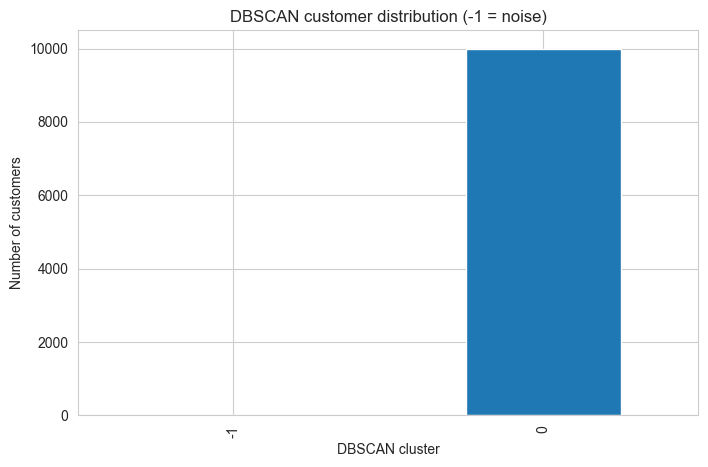

In [39]:
dbscan_counts.plot(kind="bar", figsize=(8, 5), title="DBSCAN customer distribution (-1 = noise)")
plt.xlabel("DBSCAN cluster"); plt.ylabel("Number of customers")
plt.show()

**Reading the result:** in 49 standardised dimensions almost every point has a similar distance to its neighbours, so a single `eps` either merges everything into one cluster or marks most customers as noise. DBSCAN is the weakest fit for this dataset, which is expected for evenly spread data without dense regions.

## Compare all algorithms


In [ ]:
def evaluate(name, labels):
    labels = np.asarray(labels)
    mask = labels != -1
    n_clusters = len(set(labels[mask]))
    row = {"Algorithm": name, "Clusters": n_clusters, "Noise_%": round((~mask).mean() * 100, 2)}
    if n_clusters >= 2:
        row["Silhouette_Score"] = silhouette_score(X_scaled[mask], labels[mask])
        row["Calinski_Harabasz"] = calinski_harabasz_score(X_scaled[mask], labels[mask])
        row["Davies_Bouldin"] = davies_bouldin_score(X_scaled[mask], labels[mask])
    else:
        row["Silhouette_Score"] = row["Calinski_Harabasz"] = row["Davies_Bouldin"] = np.nan
    return row

comparison_df = pd.DataFrame([
    evaluate("K-Means", df_cluster["Cluster"]),
    evaluate("Hierarchical", df_cluster["Hierarchical_Cluster"]),
    evaluate("DBSCAN", df_cluster["DBSCAN_Cluster"]),
])
comparison_df.round(4)

,Algorithm,Clusters,Noise_%,Silhouette_Score,Calinski_Harabasz,Davies_Bouldin
0,K-Means,5,0.00,0.0631,294.6891,3.7350
1,Hierarchical,3,0.00,0.0522,210.4892,3.7811
2,DBSCAN,1,0.03,NaN,NaN,NaN


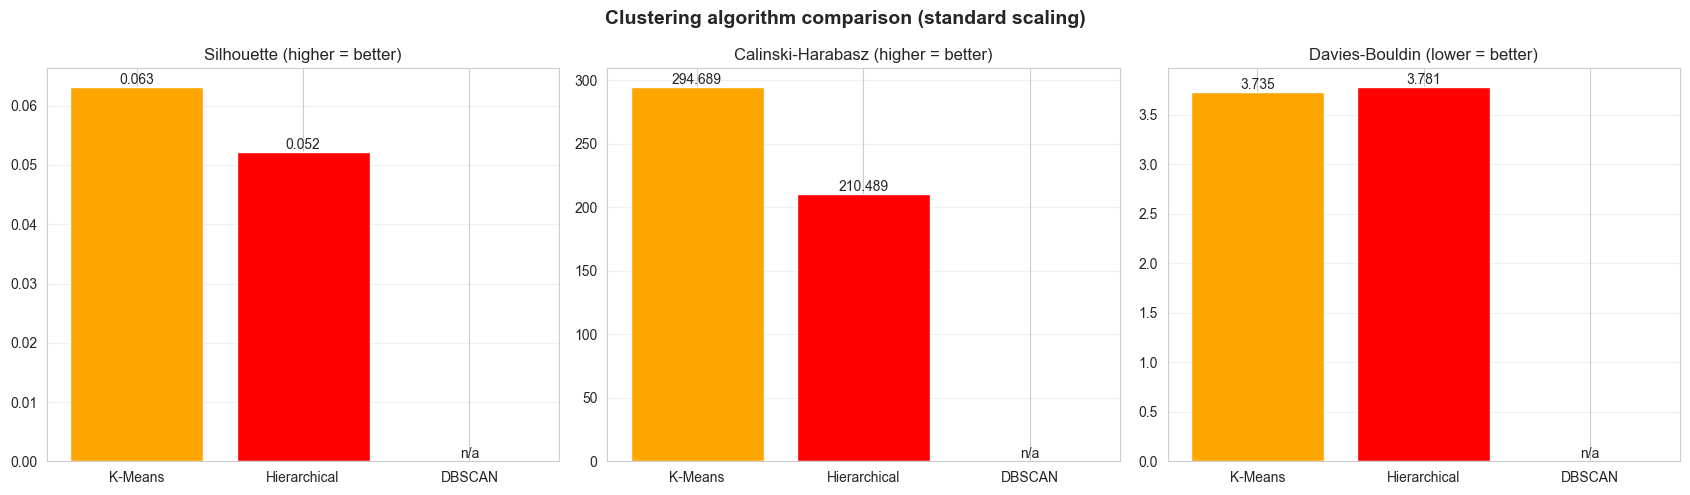

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
palette = ["orange", "red", "green", "purple"]
for ax, metric, title in zip(axes,
        ["Silhouette_Score", "Calinski_Harabasz", "Davies_Bouldin"],
        ["Silhouette (higher = better)", "Calinski-Harabasz (higher = better)", "Davies-Bouldin (lower = better)"]):
    bars = ax.bar(comparison_df["Algorithm"], comparison_df[metric].fillna(0), color=palette)
    ax.set_title(title); ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, comparison_df[metric]):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), "n/a" if np.isnan(v) else f"{v:.3f}",
                ha="center", va="bottom")
plt.suptitle("Clustering algorithm comparison (standard scaling)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 13. Final segmentation and save results

In [ ]:
final_choice = comparison_df.loc[comparison_df["Silhouette_Score"].idxmax(), "Algorithm"]
print("Algorithm with the highest silhouette score:", final_choice)

final_col = label_cols[final_choice]
df_cluster["Final_Cluster"] = df_cluster[final_col]
final_profile = df_cluster.groupby("Final_Cluster")[profile_cols].mean().round(2)
final_profile.T

Algorithm with the highest silhouette score: K-Means


Final_Cluster,0,1,2,3,4
Customer_Age,54.11,54.29,54.43,54.44,53.71
Annual_Income,49786.80,50083.99,49751.83,49638.69,50564.55
Tenure_Years,3.03,2.99,3.00,3.02,3.03
Family_Size,3.01,2.96,2.03,1.96,1.98
Last_Purchase_Recency,49.98,49.66,49.31,49.51,49.51
Spent_Wine,487.39,509.50,498.79,497.49,496.41
Spent_Fruits,49.85,49.46,49.68,49.45,50.12
Spent_Meat,400.66,393.98,402.49,405.15,403.84
Spent_Fish,149.60,148.20,147.17,151.64,147.38
Spent_Sweets,100.63,100.51,97.60,98.63,99.39


In [ ]:
df_cluster.to_csv("customer_data_clustered.csv", index=False)
print("Saved customer_data_clustered.csv", df_cluster.shape)
df_cluster[["Customer_ID", "Cluster", "KMeans_Segment", "Hierarchical_Cluster", "DBSCAN_Cluster"]].head(10)

Saved customer_data_clustered.csv (10000, 52)


,Customer_ID,Cluster,KMeans_Segment,Hierarchical_Cluster,DBSCAN_Cluster
0,1,2,Widow customers,0,0
1,2,2,Widow customers,1,0
2,3,1,Married customers,1,0
3,4,2,Widow customers,0,0
4,5,1,Married customers,0,0
5,6,0,Together customers,0,0
6,7,2,Widow customers,0,0
7,8,0,Together customers,0,0
8,9,2,Widow customers,1,0
9,10,0,Together customers,0,0


## 14. Summary and conclusions



**Results on this dataset**

| Algorithm | Chosen setting | Silhouette | Comment |
|---|---|---|---|
| K-Means | K = 5 | 0.063 (best) | clusters = the five `Marital_Status` groups |
| Hierarchical (Ward) | K = 3 | 0.052 | one big group (~83%) plus two small groups |
| DBSCAN | - | n/a | no usable split; the data forms one dense group |

**Key takeaways**
1. **K-Means is the best of the four** by silhouette, Calinski-Harabasz and Davies-Bouldin among the algorithms that produced a real segmentation, but its score (~0.06) is still very low, i.e. the clusters overlap heavily.
2. The K-Means clusters are simply the **marital-status groups**; within them, spending, income, age, purchase channels and campaign response are almost identical. `Together` and `Married` customers have larger households (about 3 people versus 2).
